In [34]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import seaborn as sns

import tensorflow as tf
from keras import layers, models, losses
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [35]:
from keras.callbacks import Callback

In [36]:
def student_model(num_classes):
    
    input_shapes = (32, 32, 100, 1)
    
    model = models.Sequential()        
    model.add(layers.TimeDistributed(layers.Conv2D(16, (3, 3), activation='relu'),input_shape=input_shapes))    
    model.add(layers.TimeDistributed(layers.MaxPooling2D((2, 2))))    
    
    model.add(layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu')))    
    model.add(layers.TimeDistributed(layers.MaxPooling2D((2, 2))))    
  
    model.add(layers.TimeDistributed(layers.Flatten()))        

    model.add(layers.LSTM(16))   
    model.add(layers.Dense(16, activation='relu'))       
    model.add(layers.Dense(num_classes, activation='softmax'))     
    #model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])        
    # model.fit(data, labels, epochs=20, batch_size=14, validation_split=0.3, shuffle=True)

    #print("\nStudent model summary:")
    #model.summary()
    return model
    
class Distiller(tf.keras.Model):
    def __init__(self, student, teacher, temperature=1.0, alpha=0.5):
        super(Distiller, self).__init__()
        self.student = student
        self.teacher = teacher
        self.temperature = temperature
        self.alpha = alpha
        #self.student_loss_fn = losses.BinaryCrossentropy()
        self.student_loss_fn = losses.SparseCategoricalCrossentropy()
        self.distillation_loss_fn = losses.KLDivergence()
        #self.metrics = tf.keras.metrics.BinaryAccuracy(name="accuracy")
        self.metric = tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")

    def compile(self, optimizer):
        super(Distiller, self).compile()
        self.optimizer = optimizer

    def train_step(self, data):
        x, y_true = data

        # 前向傳播
        teacher_pred = self.teacher(x, training=False)#即x輸入給teacher使之輸出(predict)
        with tf.GradientTape() as tape:
            student_pred = self.student(x, training=True)#即x輸入給student使之輸出(predict)

            # student 對真實 label 的 loss
            student_loss = self.student_loss_fn(y_true, student_pred)#計算student對真實label的loss

            # distillation loss (soft target)，注意加上 temperature 的處理
            teacher_soft = tf.nn.sigmoid(teacher_pred / self.temperature)
            student_soft = tf.nn.sigmoid(student_pred / self.temperature)
            distill_loss = self.distillation_loss_fn(teacher_soft, student_soft)

            # 總損失
            total_loss = self.alpha * student_loss + (1 - self.alpha) * distill_loss

        grads = tape.gradient(total_loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))

        self.metric.update_state(y_true, student_pred)
        return {"loss": total_loss, "accuracy": self.metric.result()}

    def test_step(self, data):
        x, y_true = data
        student_pred = self.student(x, training=False)
        loss = self.student_loss_fn(y_true, student_pred)
        self.metric.update_state(y_true, student_pred)
        return {"loss": loss, "accuracy": self.metric.result()}

def fit_model(train_data, train_labels, valid_data, valid_labels, callback, parameter_epoch):#
    
    student = student_model(3)  # 使用自定義的 student 架構

    teacher_model_path=r"D:\gesture_recognition_by_mmWave_and_AI\knowledge_distillation\teacher_model\gesture_model_RDI_data.h5"
    teacher = models.load_model(teacher_model_path)  # 載入教師模型
    teacher.trainable = False  # 凍結權重
    
    distiller = Distiller(student=student, teacher=teacher)#, temperature=1.25, alpha=0.7
    distiller.compile(optimizer=tf.keras.optimizers.Adam())
    distiller.fit(x=train_data, y=train_labels, validation_data=(valid_data, valid_labels), callbacks=callback, epochs=parameter_epoch, batch_size=int(train_data.shape[0]/5.0), shuffle=True)#
    return distiller


In [37]:
class EpochSaver(Callback):
    def __init__(self, save_every=10):
        super(EpochSaver, self).__init__()
        self.save_every = save_every

    def on_epoch_end(self, epoch, logs=None):
        if (epoch+1) % self.save_every == 0:

            filename = r"D:\mmWave_gesture\data_and_model\model\diff_ep_KD_label\KD_model_{}.h5".format(epoch+1)
            print("\nfile name: ", filename) 
            self.model.student.save(filename)
            print(f'\nSaved: {filename}')

In [38]:
train_data_path=r"D:\gesture_recognition_by_mmWave_and_AI\knowledge_distillation\processed_data\KD_train_0.5.npz"
train_data=np.load(train_data_path)['data']
train_labels=np.load(train_data_path)['labels']

val_data_path=r"D:\gesture_recognition_by_mmWave_and_AI\processed_data\val.npz"
val_data=np.load(val_data_path)['data']
val_data_labels=np.load(val_data_path)['labels']

test_data_path=r"D:\gesture_recognition_by_mmWave_and_AI\processed_data\test.npz"
test_data=np.load(test_data_path)['data']
test_labels=np.load(test_data_path)['labels']

In [39]:
callback_list=[EpochSaver(save_every=10)]

In [40]:
ep=300

In [41]:
KD=fit_model(train_data, train_labels, val_data, val_data_labels,parameter_epoch=ep, callback=callback_list)#

Epoch 1/300
6/6 [==============================] - 5s 397ms/step - loss: 0.5189 - accuracy: 0.5616 - val_loss: 1.0926 - val_accuracy: 0.6508
Epoch 2/300
6/6 [==============================] - 2s 297ms/step - loss: 0.5227 - accuracy: 0.7123 - val_loss: 1.0616 - val_accuracy: 0.6032
Epoch 3/300
6/6 [==============================] - 2s 424ms/step - loss: 0.5047 - accuracy: 0.6986 - val_loss: 1.0714 - val_accuracy: 0.5238
Epoch 4/300
6/6 [==============================] - 3s 524ms/step - loss: 0.4680 - accuracy: 0.6712 - val_loss: 1.0292 - val_accuracy: 0.6508
Epoch 5/300
6/6 [==============================] - 2s 304ms/step - loss: 0.4356 - accuracy: 0.7123 - val_loss: 0.9733 - val_accuracy: 0.6032
Epoch 6/300
6/6 [==============================] - 2s 291ms/step - loss: 0.3894 - accuracy: 0.7123 - val_loss: 1.0549 - val_accuracy: 0.6508
Epoch 7/300
6/6 [==============================] - 2s 280ms/step - loss: 0.3730 - accuracy: 0.6986 - val_loss: 0.9105 - val_accuracy: 0.6508
Epoch 8/300
6

d:\mmWave_gesture\gesture_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


6/6 [==============================] - 2s 277ms/step - loss: 0.2990 - accuracy: 0.7260 - val_loss: 0.7067 - val_accuracy: 0.6667
Epoch 12/300
6/6 [==============================] - 2s 267ms/step - loss: 0.2592 - accuracy: 0.7260 - val_loss: 0.7033 - val_accuracy: 0.6508
Epoch 13/300
6/6 [==============================] - 2s 372ms/step - loss: 0.2671 - accuracy: 0.7260 - val_loss: 0.7610 - val_accuracy: 0.6349
Epoch 14/300
6/6 [==============================] - 2s 275ms/step - loss: 0.3234 - accuracy: 0.7397 - val_loss: 0.8769 - val_accuracy: 0.6667
Epoch 15/300
6/6 [==============================] - 2s 258ms/step - loss: 0.2929 - accuracy: 0.7397 - val_loss: 0.7467 - val_accuracy: 0.6508
Epoch 16/300
6/6 [==============================] - 2s 321ms/step - loss: 0.2345 - accuracy: 0.7260 - val_loss: 0.6418 - val_accuracy: 0.6667
Epoch 17/300
6/6 [==============================] - 2s 304ms/step - loss: 0.3135 - accuracy: 0.7260 - val_loss: 0.8070 - val_accuracy: 0.6667
Epoch 18/300
6/6 [=

In [42]:
epochs_record =list()

train_accuracy =list()
test_accuracy =list()

train_loss =list()
test_loss =list()

In [43]:
for epoch in range(10,ep+10,10):
    print("\nepoch : ", epoch)
    KD_model_path=r"D:\mmWave_gesture\data_and_model\model\diff_ep_KD_label\KD_model_{}.h5".format(epoch)
    
    KD_model=models.load_model(KD_model_path)  # 載入教師模型
    
    KD_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    loss_train, acc_train = KD_model.evaluate(train_data, train_labels)
    loss_test, acc_test = KD_model.evaluate(test_data, test_labels)
    
    epochs_record.append(epoch)
    
    train_accuracy.append(acc_train*100)
    test_accuracy.append(acc_test*100)
    
    train_loss.append(loss_train)
    test_loss.append(loss_test)



epoch :  10
3/3 [==============================] - 0s 107ms/step - loss: 0.6402 - accuracy: 0.6556

epoch :  20
3/3 [==============================] - 1s 183ms/step - loss: 0.5086 - accuracy: 0.7000

epoch :  30
3/3 [==============================] - 1s 194ms/step - loss: 0.4816 - accuracy: 0.7667

epoch :  40
3/3 [==============================] - 0s 103ms/step - loss: 0.8314 - accuracy: 0.5444

epoch :  50
3/3 [==============================] - 0s 106ms/step - loss: 0.4360 - accuracy: 0.8444

epoch :  60
3/3 [==============================] - 1s 183ms/step - loss: 0.3969 - accuracy: 0.9000

epoch :  70
3/3 [==============================] - 0s 116ms/step - loss: 0.3714 - accuracy: 0.8778

epoch :  80
3/3 [==============================] - 0s 104ms/step - loss: 0.3824 - accuracy: 0.8778

epoch :  90
3/3 [==============================] - 0s 104ms/step - loss: 0.3638 - accuracy: 0.8778

epoch :  100
3/3 [==============================] - 1s 171ms/step - loss: 0.4029 - accuracy: 0.8778

In [44]:
df = pd.DataFrame({
    'Epoch': epochs_record,
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'Train Loss': train_loss,
    'Test Loss': test_loss
})

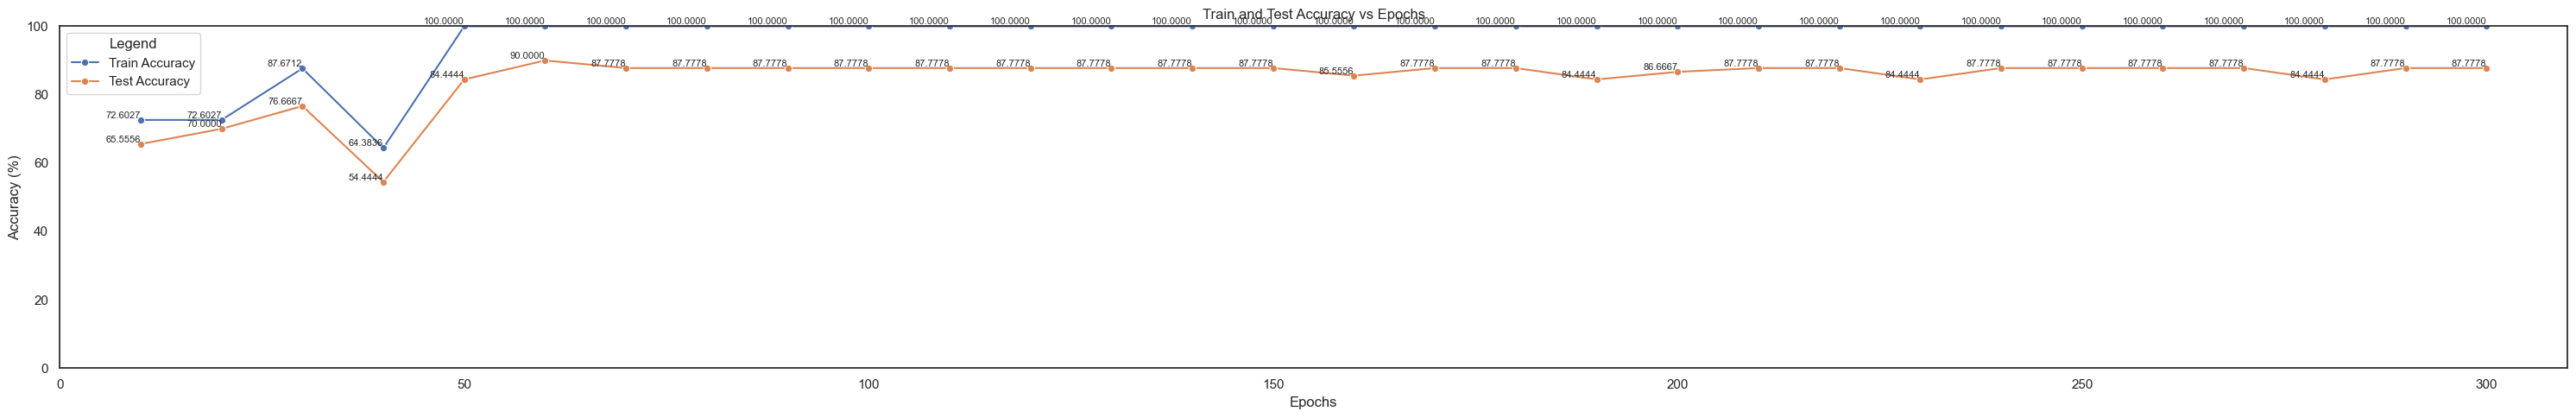

In [45]:
# 設定 Seaborn 樣式
sns.set(style='white')  # 白色背景、無格線

# ---------- 圖1：Accuracy ----------
plt.figure(figsize=(30, 5))
sns.lineplot(x='Epoch', y='value', hue='variable',
             data=pd.melt(df, ['Epoch'], value_vars=['Train Accuracy', 'Test Accuracy']),
             marker='o')

for x, y in zip(epochs_record, train_accuracy):
    plt.text(x, y, f'{y:.4f}', ha='right', va='bottom', fontsize=8)
for x, y in zip(epochs_record, test_accuracy):
    plt.text(x, y, f'{y:.4f}', ha='right', va='bottom', fontsize=8)
    
plt.title('Train and Test Accuracy vs Epochs')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.xlabel('Epochs')
plt.xlim(0, ep+10)
plt.legend(title='Legend')
plt.tight_layout()
plt.show()


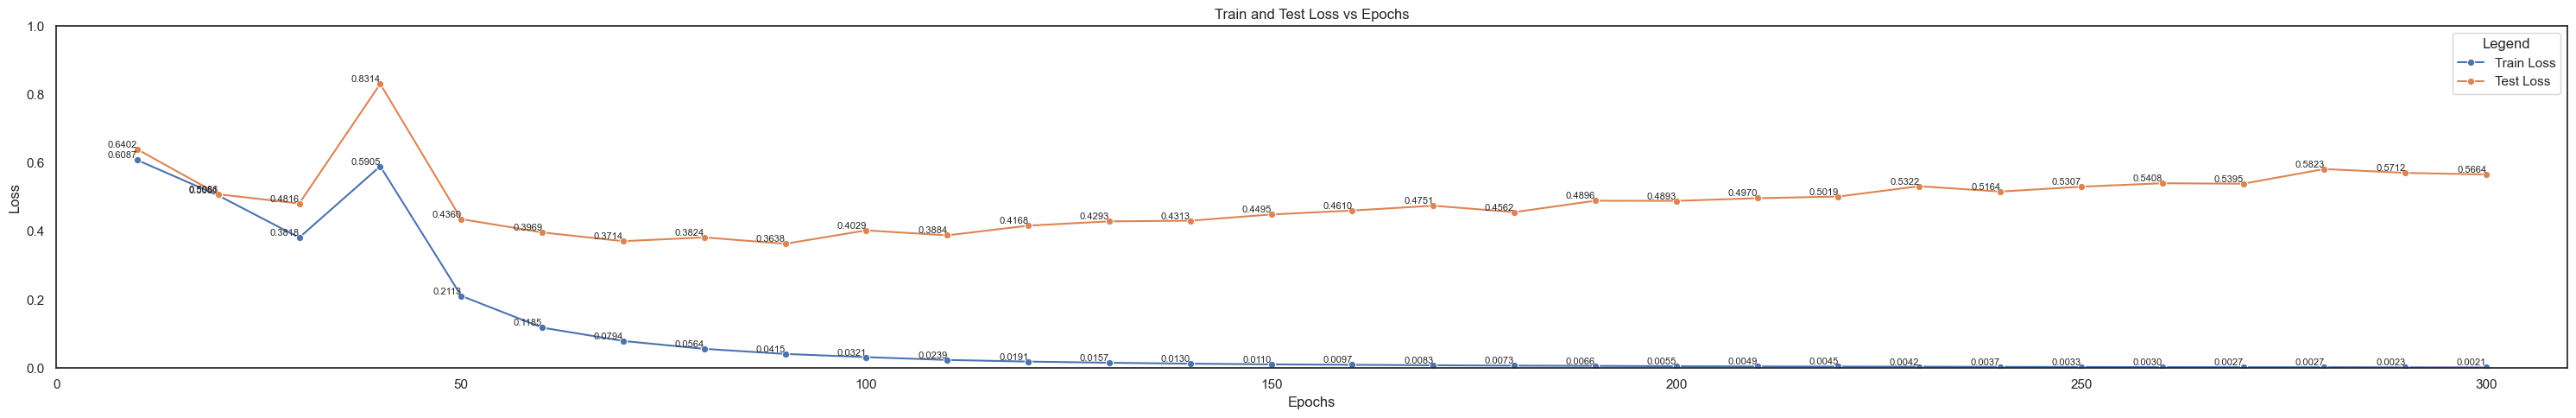

In [46]:
plt.figure(figsize=(30, 5))
sns.lineplot(x='Epoch', y='value', hue='variable',
             data=pd.melt(df, ['Epoch'], value_vars=['Train Loss', 'Test Loss']),
             marker='o')

for x, y in zip(epochs_record, train_loss):
    plt.text(x, y, f'{y:.4f}', ha='right', va='bottom', fontsize=8)
for x, y in zip(epochs_record, test_loss):
    plt.text(x, y, f'{y:.4f}', ha='right', va='bottom', fontsize=8)
plt.title('Train and Test Loss vs Epochs')
plt.ylabel('Loss')
plt.ylim(0, 1)  # 可依你的實際 loss 調整
plt.xlabel('Epochs')
plt.xlim(0, ep+10)
plt.legend(title='Legend')
plt.tight_layout()
plt.show()